# Validation Narrabeen

## Paths & Co

In [1]:
new_kalman_run = True
animation = True

In [2]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

# paths jupyter utwente
path_tc = path_to_data_folder + '01_tides/output/'
path_validation = path_to_data_folder + '03_Narrabeen_validation_data/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '32_33_Narrabeen_DEM/input/'
path_output = path_to_data_folder + '32_33_Narrabeen_DEM/output/'
path_altimetry_output = path_to_data_folder + '31_Narra_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n-33.6_s-33.8_w151.2_e151.4.nc'
fn_ddtm = 'DeltaDTM_v1_0_S34E151.tif'

epsg = 4326 # WGS84
epsg_local = 32356

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore")

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation
import P2_functions

In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [5]:
# Observational noise
sigma_l = 0.35

# Model noise
factor = 10
sigma_q = factor * sigma_l

# Standard deviation of the initial state
std_init = 3

print(f'Observational noise: {round(sigma_l,2)} m')
print(f'Model noise: {round(sigma_q,2)} m')
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.35 m
Model noise: 3.5 m
Standard deviation of the initial state: 3 m


In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Observations

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32356.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Tidal correction
fn = 'tides_narra.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [9]:
# Cassie shorelines
folders = ['2_1992-09-24_1998-04-18_spac100_ext400_thresh0/',
          '3_1998-05-20_2007-09-18_spac100_ext400_thresh0/',
          '4_2007-10-04_2016-10-28_spac100_ext400_thresh0/',
          '5_2016-11-13_2021-10-26_spac100_ext400_thresh0/',
          '6_2021-12-13_2025-04-20_spac100_ext300_thresh0/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

263 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 115 points (min: 34, max: 143).


In [10]:
# number of shorelines per year
num_imgs = pd.DataFrame([_.year for _ in c_dates]).value_counts(sort=False)
num_imgs = num_imgs.reset_index(level=[0])
num_imgs.to_pickle(path_output+'num_imgs_Narra.pkl')

In [11]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_output + 'c_shorelines_corr.pkl', 'rb'))
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

### Validation data

In [12]:
vali_gdf = gpd.read_file(path_output + 'narra_vali_gdf.geojson')

### Initial state

In [13]:
init = xr.open_dataset(path_output+'init_4326_resolution_50m.tif').squeeze()

### Polygons

In [14]:
poly_sl_corr = pickle.load(open(path_output + f'poly_sl_corr{epsg}.pkl', 'rb'))
profile_polys = pickle.load(open(path_output + 'profile_polys.pkl', 'rb'))
profile_polys_red = pickle.load(open(path_output + 'profile_polys_red.pkl', 'rb'))

In [15]:
for area in profile_polys_red.keys():
    poly_local = CD_geometry.transform_polygon(profile_polys[area], 4326, epsg_local)
    print(f'Surface area of {area}: {round(poly_local.area/1e6, 3)} km^2')

Surface area of PF1: 0.022 km^2
Surface area of PF2: 0.019 km^2
Surface area of PF4: 0.019 km^2
Surface area of PF6: 0.015 km^2
Surface area of PF8: 0.016 km^2


## Generate RTS-DTM

In [32]:
year_ref = 2006
n_iter = 2

fn = 'x_state_s_readd.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    # Initialise state vector
    init_df = init.to_dataframe().dropna()
    x = init_df.index.get_level_values('x')
    y = init_df.index.get_level_values('y')    
    x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
    x_state = x_state.set_crs(epsg)

    # Covariance matrix of the initial state
    sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
    sigma_xx_init = diags_array(sigma_xx_init_df.sigma)    
    # with correlations
    # sigma_xx_init = CD_kalman.build_covMatrix(x_state, std_init, epsg_local, n_neighbours=10)

    # "Iteration 0"
    x_k = x_state['init'].copy()
    sigma_xx_k = sigma_xx_init

    # Initial trend 
    trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

    for j in range(0, n_iter):
        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
              x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
              seg_length, alt, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
              max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)

        # New trend
        trends[f'trend_{j}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
        # Overwrite  trend_k for next iteration
        trends['trend_k'] = trends[f'trend_{j}'].copy()

        # Overwrite x_k so that next iteration starts with residuals and not the full signal
        x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
        sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

    # Re-add trend
    x_state_readd = x_state.copy()
    x_state_s_readd = x_state_s.copy()

    all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
    trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

    year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
    for year in year_list:
        deltaYear = year - year_ref
        x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
        x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
        x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

    kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state_readd, x_state_s_readd)

    # Save kf output
    pickle.dump(x_state_readd, open(f'{path_output}x_state_readd.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s_readd, open(f'{path_output}x_state_s_readd.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state_readd.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s_readd.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

Forward run done. Needed  23.6 seconds.
Forward run done. Needed  25.2 seconds.
Backward run done. Needed  6.2 seconds.
Interpolation done. Needed  0.2 seconds.


## Remove height difference between validation and new DTM
from different height reference systems

In [74]:
diff_kf = kf_interp.drop(columns=['geometry']) - vali_gdf.drop(columns=['geometry'])
diff_rts = rts_interp.drop(columns=['geometry']) - vali_gdf.drop(columns=['geometry'])
diff_kf_rts = pd.concat([diff_kf, diff_rts], axis=0)

print(f'Mean of all differences (KF-Jarkus and RTS-validation): {round(diff_kf_rts.mean().mean(), 2)}, median: {round(diff_kf_rts.median().median(), 2)}')
bias = diff_kf_rts.median().median()
vali_red = vali_gdf.copy()
vali_red.loc[:, vali_red.columns != 'geometry'] += bias

Mean of all differences (KF-Jarkus and RTS-validation): -1.43, median: -0.64


In [75]:
pickle.dump(bias, open(path_output+'bias.pkl', 'wb'))

## Statistics of elevation differences (averaged over all profiles)

In [76]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(vali_red.geometry.x, vali_red.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', vali_red.geometry.x, vali_red.geometry.y)

In [77]:
# Reduce to area inside the shoreline polygon
init_inside_sl = init_interp[init_interp.intersects(poly_sl_corr)]
vali_inside_sl = vali_red[vali_red.intersects(poly_sl_corr)]
kf_inside_sl = kf_interp[kf_interp.intersects(poly_sl_corr)]
rts_inside_sl = rts_interp[rts_interp.intersects(poly_sl_corr)]

### Initial state - validation

In [78]:
vali_temp_mean = vali_red.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - vali_temp_mean
print(f'Difference initial state - vali has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - vali has 630 non-NaN values.


In [79]:
CD_statistics.print_stats(diff_init)

Mean error: 0.25 m
---De-bias with mean---
Mean error: 0.0 m
Mean absolute error: 1.96 m
Root mean square error: 2.49 m
Mean absolute deviation from mean: 1.96 m
Median absolute deviation from median: 1.71 m


In [80]:
year_list = [int(_) for _ in vali_inside_sl.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], vali_red, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - validation

In [81]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, vali_red, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, vali_red, year_list, reduce_mean=True, static=False)

In [82]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [83]:
def plot_stats(ax, which_stat, title, legend=False):
    ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - validation')
    ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
    ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

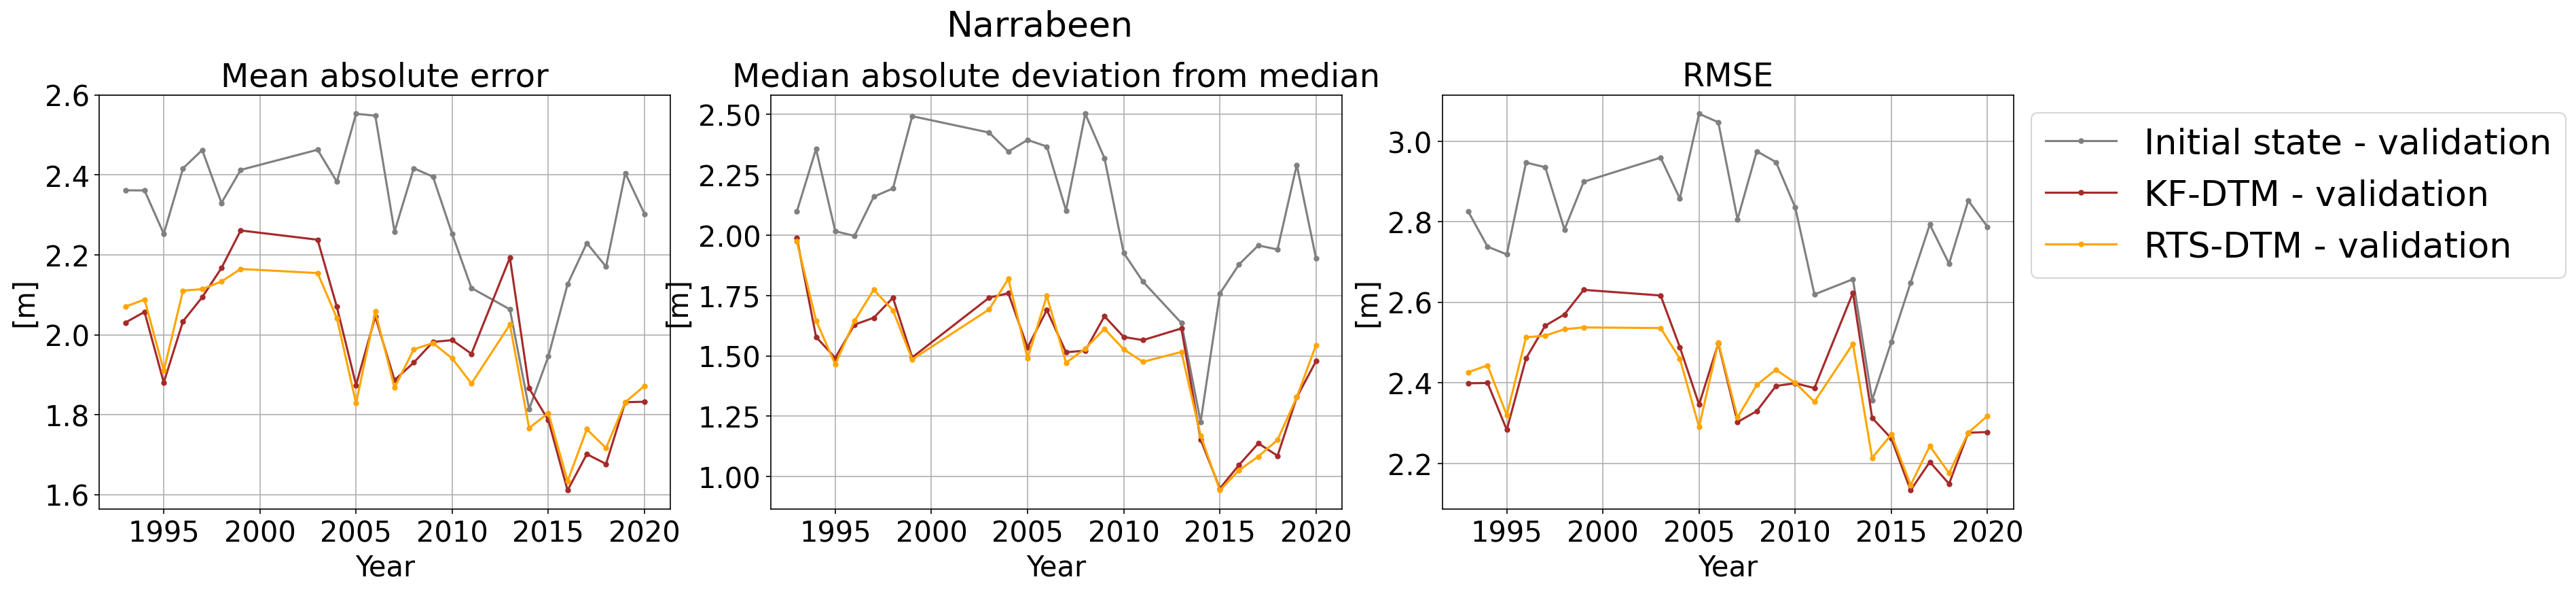

In [84]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
fig.suptitle('Narrabeen', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Narra_vali_elevation_differences.png', dpi=300, bbox_inches='tight')

#### Quantify difference init - KF/RTS
positive: init has (on average) larger error  
negative: KF/RTS has larger error  

In [44]:
print(f'Average difference init-KF:')
print(f'ME: {round((stats_gdf_init.mae - stats_gdf_kf.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init.mad_med - stats_gdf_kf.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init.rmse - stats_gdf_kf.rmse).mean(),2)} m')

print(f'\nAverage difference init-RTS:')
print(f'ME: {round((stats_gdf_init.mae - stats_gdf_rts.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init.mad_med - stats_gdf_rts.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init.rmse - stats_gdf_rts.rmse).mean(),2)} m')

Average difference init-KF:
ME: 0.34 m
MAD: 0.59 m
RMSE: 0.42 m

Average difference init-RTS:
ME: 0.35 m
MAD: 0.6 m
RMSE: 0.42 m


### Maps

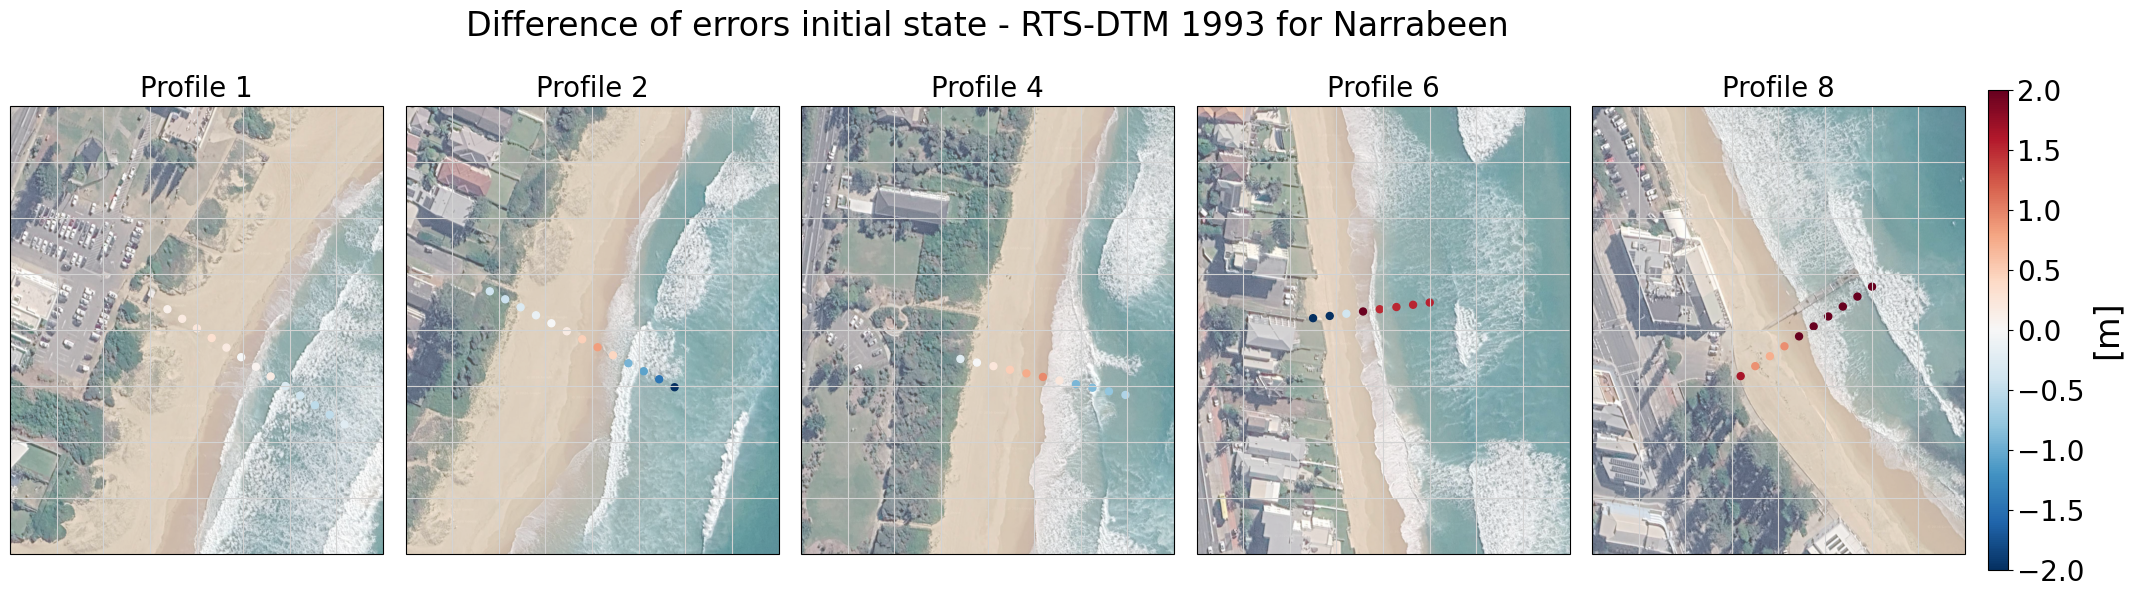

In [45]:
year = '1993'
diff_init = init_interp['init'] - vali_red[year]
diff_rts = rts_interp[year] - vali_red[year]
diff_rts_init = np.abs(diff_init) - np.abs(diff_rts)

projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
zoom = 20
fig, axs = plt.subplots(1, 5, figsize=(20,8), subplot_kw=dict(projection=request.crs))
fig.tight_layout()

x = vali_red.geometry.x
y = vali_red.geometry.y
for ax in axs:
    plot = ax.scatter(x, y, marker='o', s=25, c=diff_rts_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-2, vmax=2)

axs[0].set_extent([151.304, 151.306, -33.707, -33.705], crs=ccrs.PlateCarree())
axs[0].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[0].add_image(request, zoom, alpha=0.7, zorder=0)
axs[0].set_title('Profile 1')

axs[1].set_extent([151.3025, 151.3045, -33.7105, -33.7085], crs=ccrs.PlateCarree())
axs[1].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[1].add_image(request, zoom, alpha=0.7, zorder=0)
axs[1].set_title('Profile 2')

axs[2].set_extent([151.299, 151.301, -33.718, -33.716], crs=ccrs.PlateCarree())
axs[2].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[2].add_image(request, zoom, alpha=0.7, zorder=0)
axs[2].set_title('Profile 4')

axs[3].set_extent([151.299, 151.301, -33.726, -33.724], crs=ccrs.PlateCarree())
axs[3].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[3].add_image(request, zoom, alpha=0.7, zorder=0)
axs[3].set_title('Profile 6')

axs[4].set_extent([151.301, 151.303, -33.733, -33.731], crs=ccrs.PlateCarree())
axs[4].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[4].add_image(request, zoom, alpha=0.7, zorder=0)
axs[4].set_title('Profile 8')

cbar_ax = fig.add_axes([1, 0.2, 0.01, 0.6])
fig.colorbar(plot, cax=cbar_ax).set_label(label='[m]',size=24)

fig.suptitle(f'Difference of errors initial state - RTS-DTM {year} for Narrabeen', y=.9, fontsize=24);

plt.savefig(f'{path_output}Narra_map_diff_errors_init-RTS_{year}.png', dpi=300, bbox_inches='tight')

## Time series of volume changes

In [46]:
volumes_vali, volumes_kf, volumes_rts = P2_functions.get_all_volumes(vali_red, kf_interp, rts_interp, profile_polys, epsg_local)

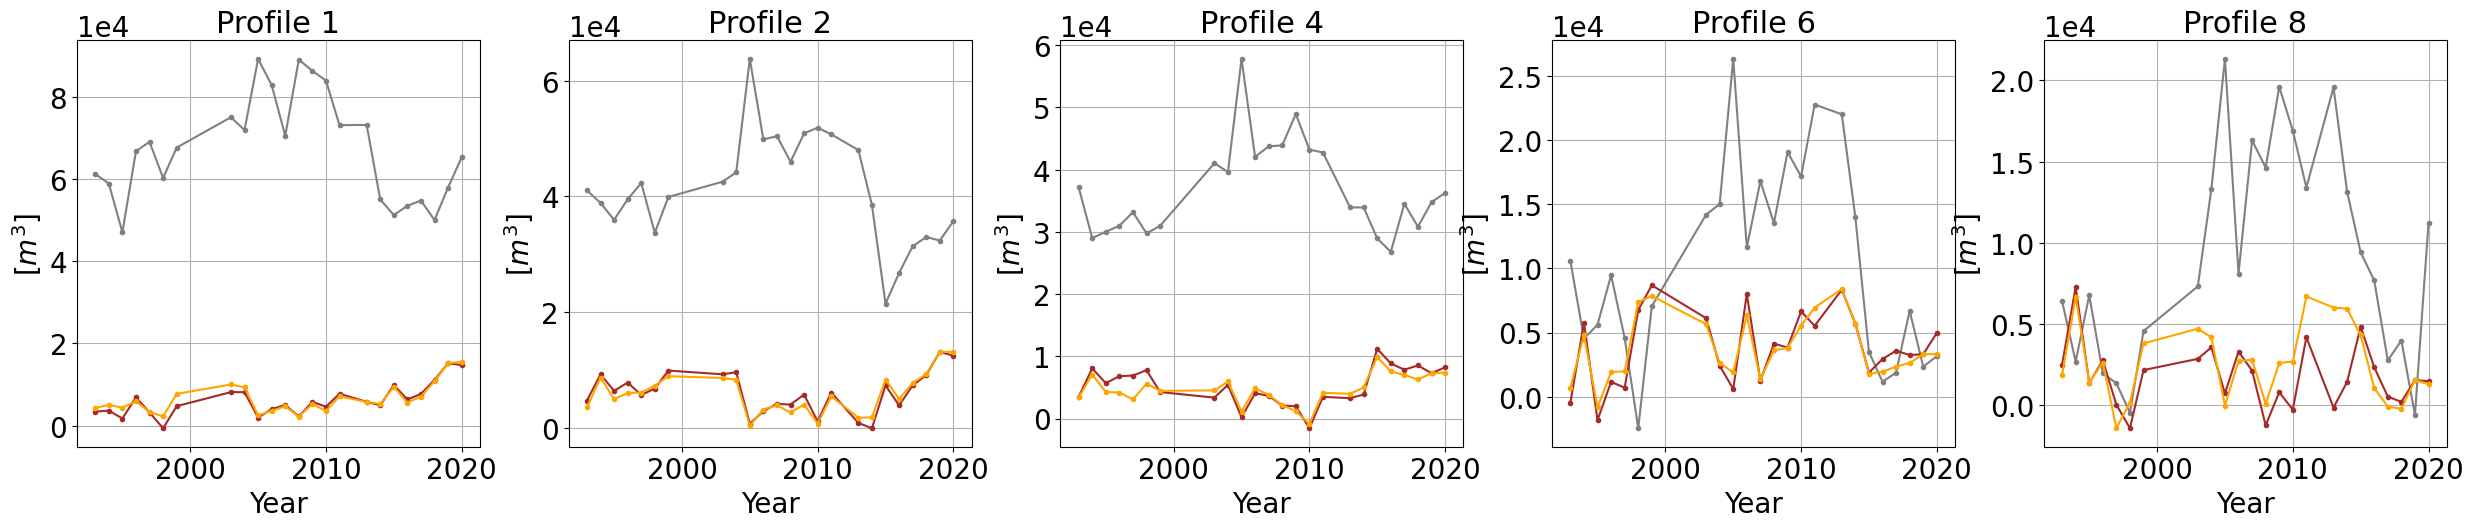

In [47]:
def plot_volume_changes(ax, vol_vali, vol_kf, vol_rts, title_area, legend=False):
    ax.plot(vol_vali.index, vol_vali, '.-', c=c_init, label='Validation')
    ax.plot(vol_kf.index, vol_kf, '.-', c=c_kf, label='KF-DTM')
    ax.plot(vol_rts.index, vol_rts, '.-', c=c_rts, label='RTS-DTM')
    ax.set_ylabel(r'[$m^3$]')
    ax.set_xlabel('Year')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_title(f'{title_area}', fontsize=22)
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=22)
                  
fig, axs = plt.subplots(1,5, figsize=(25,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.22)

plot_volume_changes(axs[0], volumes_vali['PF1'], volumes_kf['PF1'], volumes_rts['PF1'], 'Profile 1')
plot_volume_changes(axs[1], volumes_vali['PF2'], volumes_kf['PF2'], volumes_rts['PF2'], 'Profile 2')
plot_volume_changes(axs[2], volumes_vali['PF4'], volumes_kf['PF4'], volumes_rts['PF4'], 'Profile 4')
plot_volume_changes(axs[3], volumes_vali['PF6'], volumes_kf['PF6'], volumes_rts['PF6'], 'Profile 6')
plot_volume_changes(axs[4], volumes_vali['PF8'], volumes_kf['PF8'], volumes_rts['PF8'], 'Profile 8', legend=False)

plt.savefig(f'{path_output}Narrabeen_validation_volume_changes_allProfiles.png', dpi=300, bbox_inches='tight')

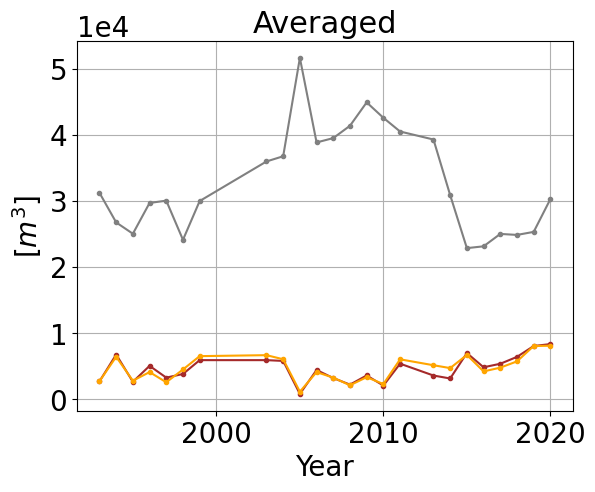

In [48]:
fig, ax = plt.subplots()
plot_volume_changes(ax, volumes_vali.mean(axis=1), volumes_kf.mean(axis=1), volumes_rts.mean(axis=1), 'Averaged')

### Comparison statistics

In [49]:
# Averaged over all profiles
trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_averaged(volumes_vali, volumes_kf, volumes_rts, print_output=True)
pickle.dump(trends, open(path_output+'Narra_validation_trends.pkl', 'wb'))

Trend differences in % of total trend: 397.88
RMSE relative to total mean volume: 26.8
Correlation:-0.47, p: 0.02


In [50]:
# For each profile individually
trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_Narrabeen(volumes_vali, volumes_kf, volumes_rts, profile_polys_red, print_output=True)
pickle.dump(trends, open(path_output+'Narra_validation_trends.pkl', 'wb'))

PF1 Trend differences in % of total trend: -262.58
PF1 RMSE relative to total mean volume: 20.9
PF1 Correlation:-0.35, p: 0.09 

PF2 Trend differences in % of total trend: -131.54
PF2 RMSE relative to total mean volume: 28.2
PF2 Correlation:-0.62, p: 0.0 

PF4 Trend differences in % of total trend: 93.49
PF4 RMSE relative to total mean volume: 24.6
PF4 Correlation:-0.67, p: 0.0 

PF6 Trend differences in % of total trend: 325.23
PF6 RMSE relative to total mean volume: 71.0
PF6 Correlation:0.21, p: 0.32 

PF8 Trend differences in % of total trend: -104.12
PF8 RMSE relative to total mean volume: 68.1
PF8 Correlation:0.27, p: 0.21 



## Animation

#### KF

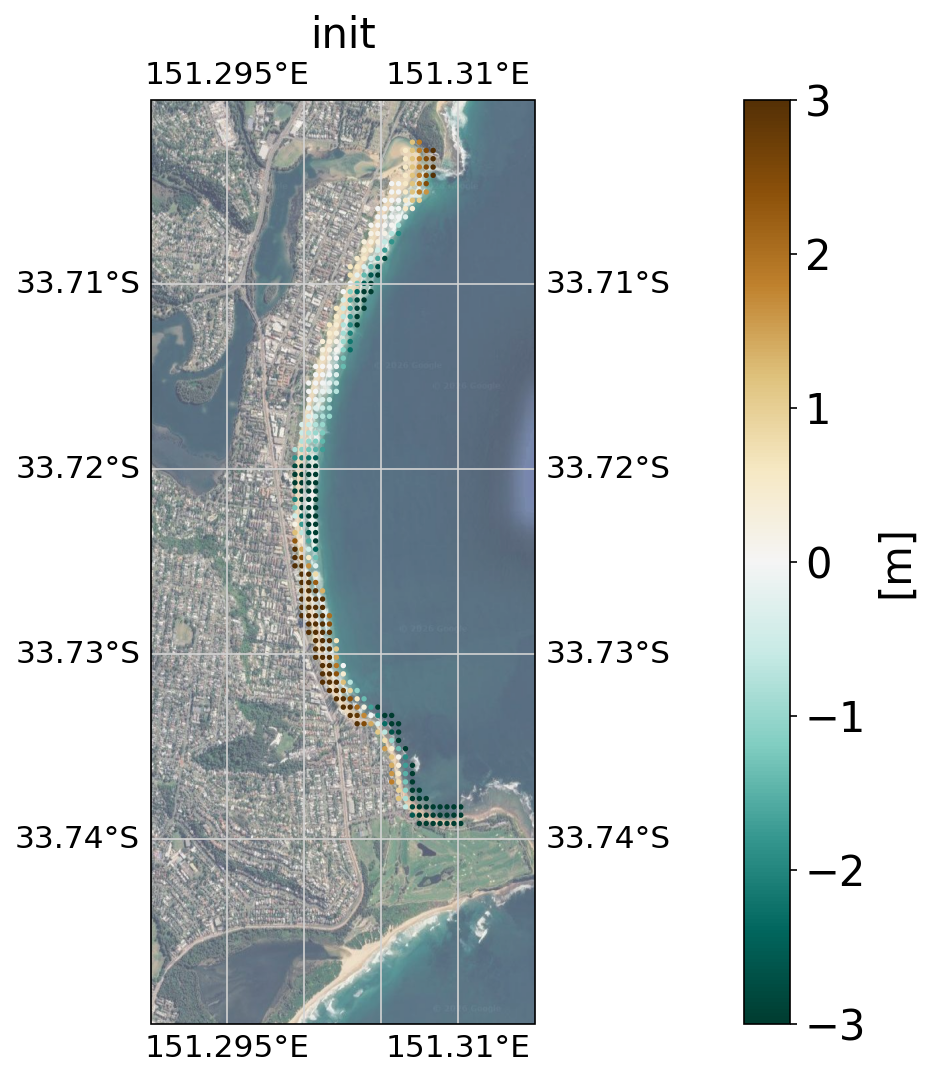

In [51]:
if animation:
    extent = [151.29, 151.315, -33.75, -33.70]
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_in_sl_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_in_sl_poly.geometry.x
    y = x_state_in_sl_poly.geometry.y
    anim = CD_visualisation.movie(x_state_in_sl_poly, x, y,
            col_list_kf, first_col='init', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='KF.gif')

#### RTS

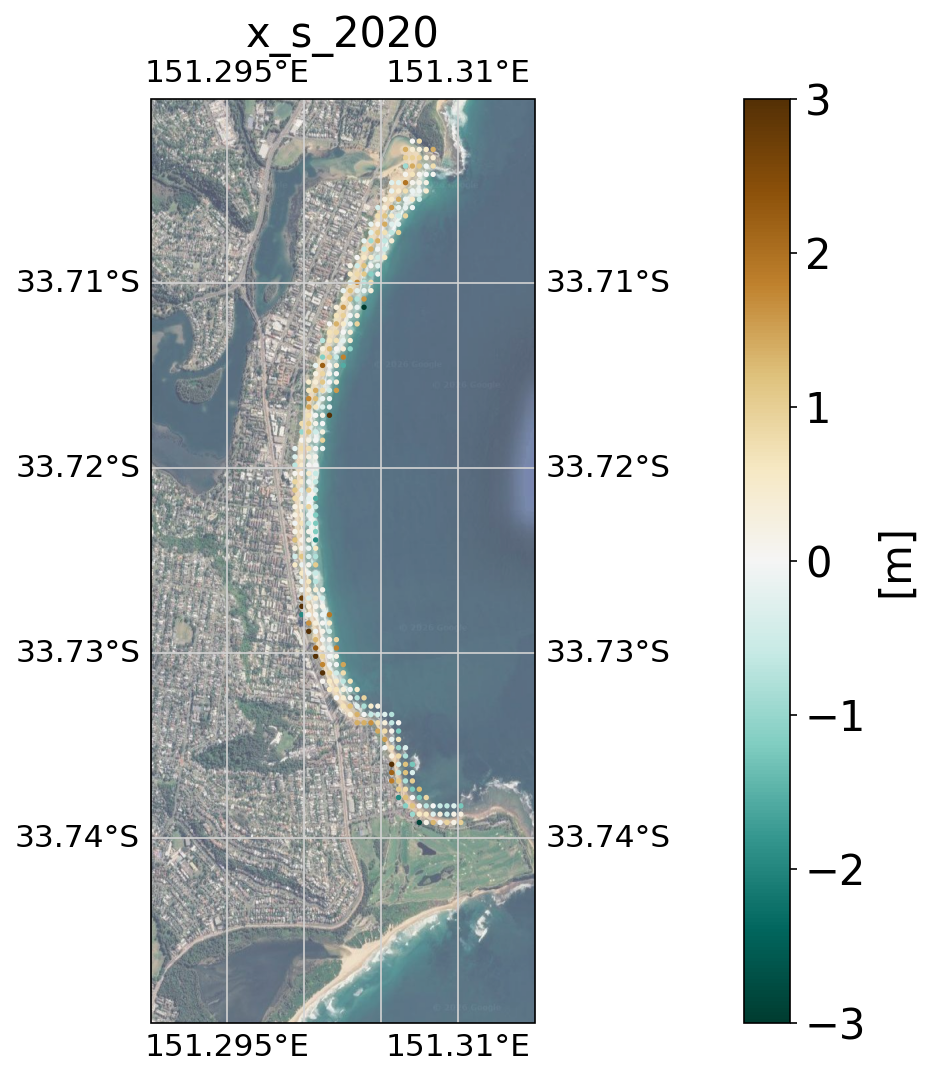

In [52]:
if animation:
    extent = [151.29, 151.315, -33.75, -33.70]
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_in_sl_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_in_sl_poly.geometry.x
    y = x_state_s_in_sl_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_in_sl_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='RTS.gif')

#### Single year result map

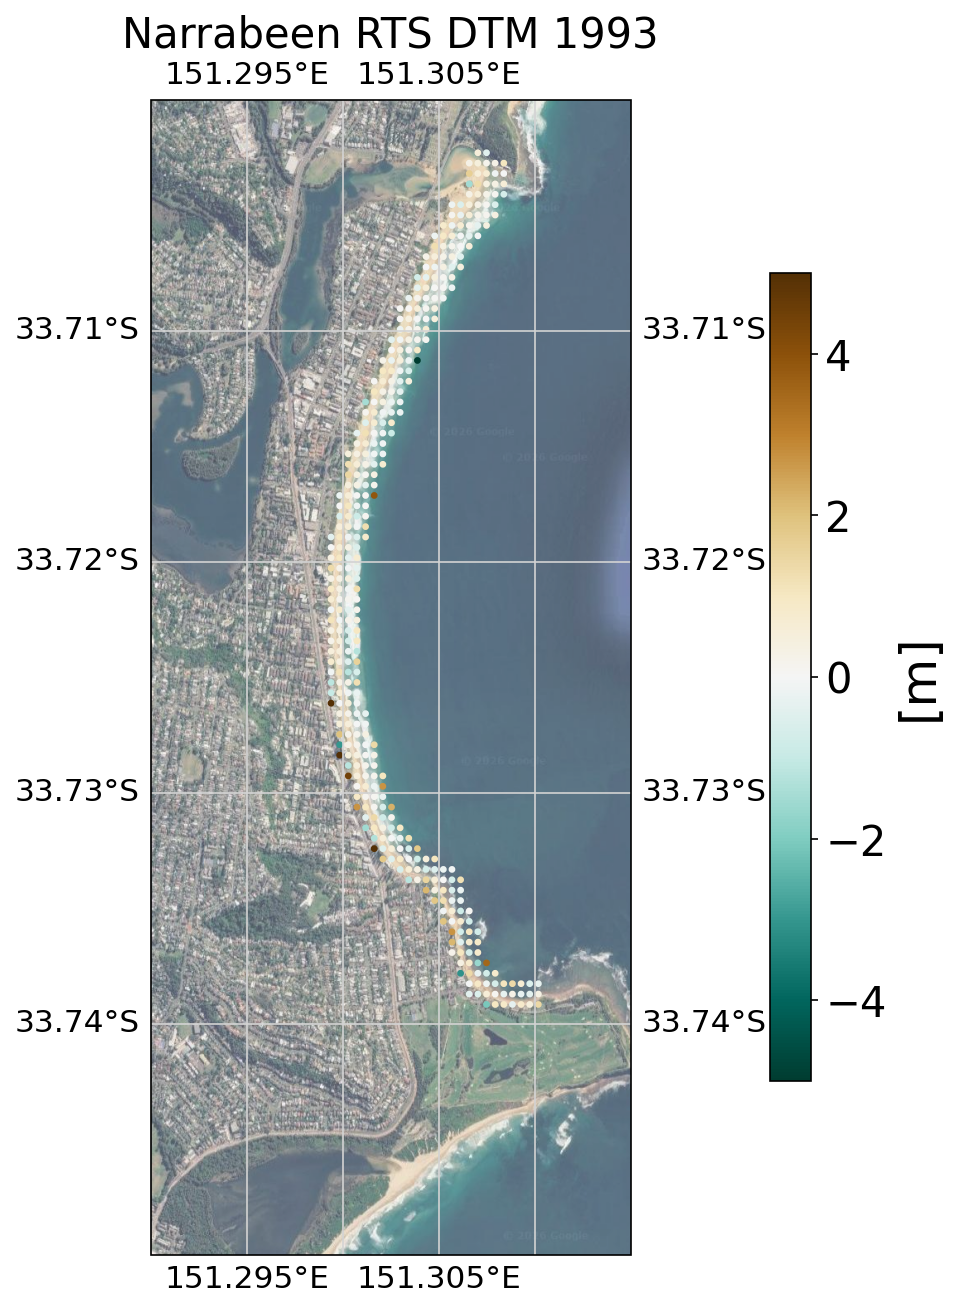

In [53]:
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
extent = [151.29, 151.315, -33.75, -33.70]
ax.set_extent(extent, crs=projection)
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 15
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = x_state.geometry.x
y = x_state.geometry.y

plot = ax.scatter(x, y, marker='o', s=5, c = x_state_s['x_s_1993'],
                  cmap='BrBG_r', transform=ccrs.PlateCarree(), vmin=-5, vmax=5)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'Narrabeen RTS DTM 1993')

plt.savefig(f'{path_output}RTS_DTM_1993.png', dpi=300, bbox_inches='tight')

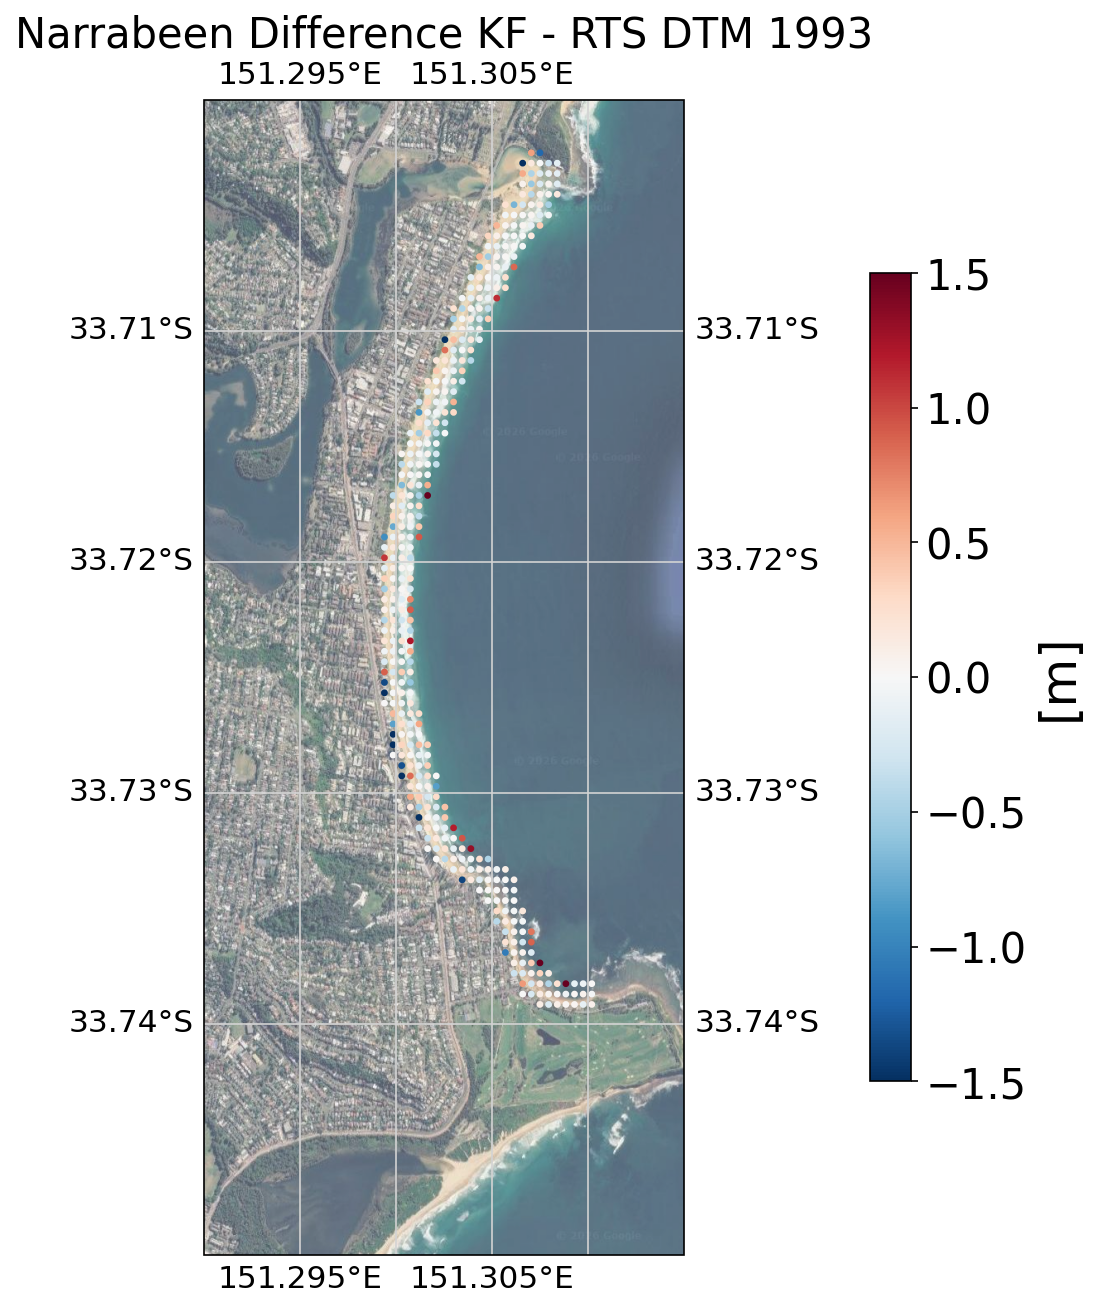

In [54]:
diff = x_state_s['x_s_1993'] - x_state['x_up_1993']

fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, marker='o', s=5, c=diff,
                  cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-1.5, vmax=1.5)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Narrabeen Difference KF - RTS DTM 1993');

plt.savefig(f'{path_output}diff_kf-rts_1993.png', dpi=300, bbox_inches='tight')

### Map of variances

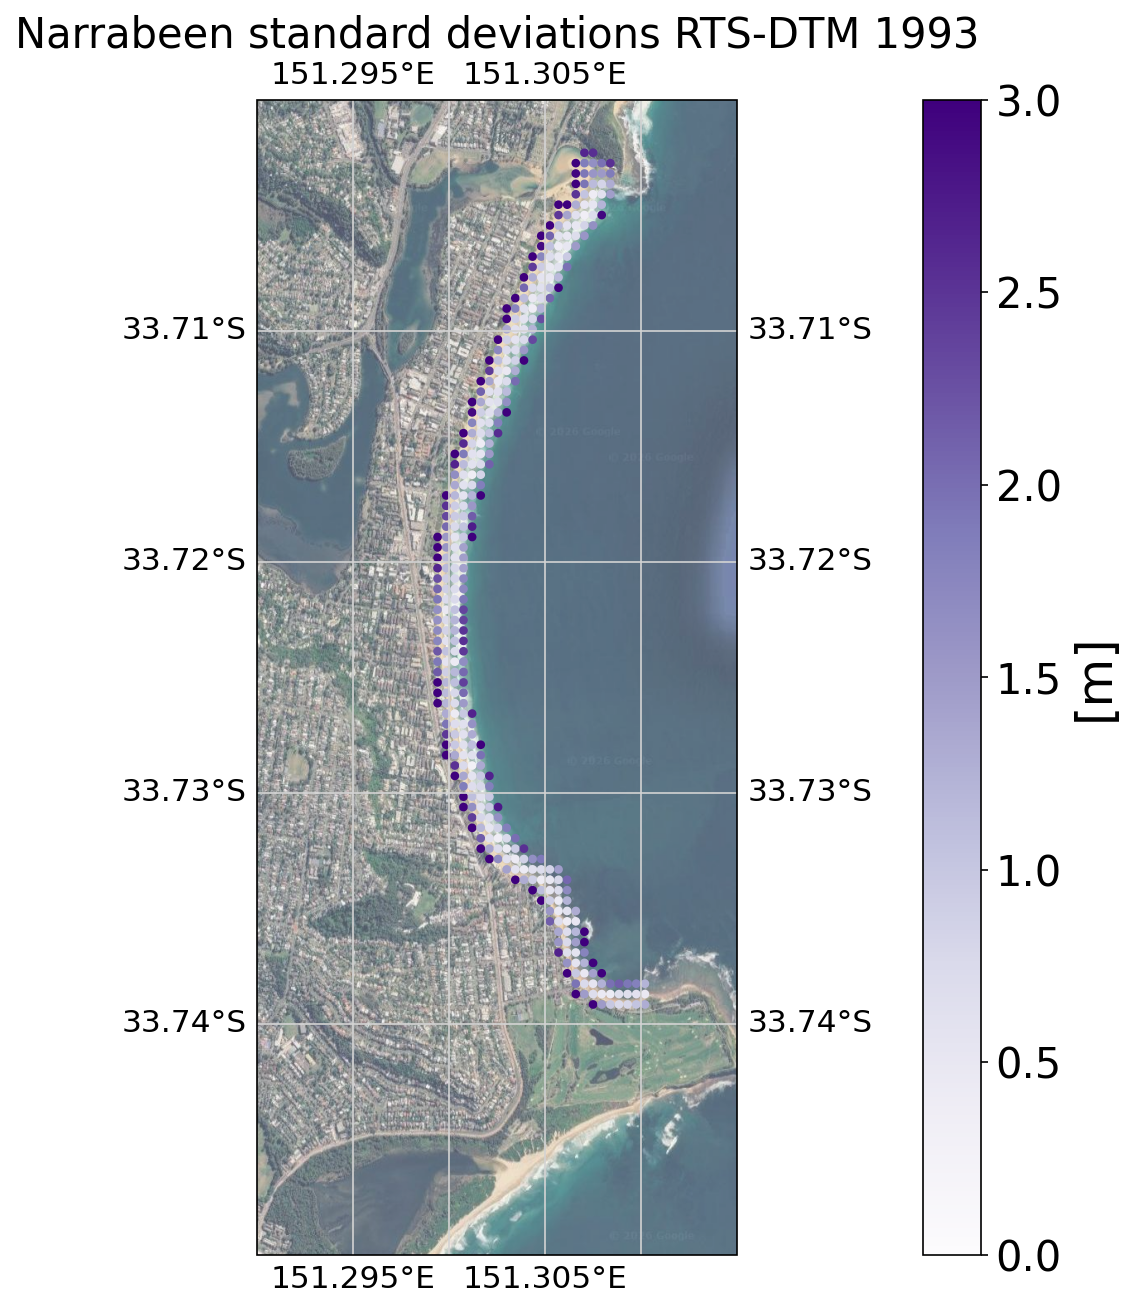

In [55]:
extent = [151.29, 151.315, -33.75, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15, background=True)
x = x_state.geometry.x
y = x_state.geometry.y
data = np.diagonal(sigma_xx_s['1993'].toarray())
data = np.sqrt(data)
plot = ax.scatter(x, y, marker='o', s=10, c = data,
                  cmap='Purples', transform=ccrs.PlateCarree(), vmin=0, vmax=3)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Narrabeen standard deviations RTS-DTM 1993')
plt.savefig(f'{path_output}std_1993.png', dpi=300, bbox_inches='tight')
# !!! some values at the landward edge go up to 10